# 🎓 Student Performance Predictor — Revised Project
## Logistic Regression vs Decision Tree | UCI Portuguese Language Dataset
---
### How to Run:
- Click **Runtime → Run All** to run everything at once
- OR run each cell one by one from top to bottom

### What This Notebook Does:
1. ✅ Installs all libraries
2. ✅ Downloads and loads UCI Portuguese Language dataset (649 students)
3. ✅ Trains 2 ML models: Logistic Regression and Decision Tree
4. ✅ Generates and saves all result charts
5. ✅ Generates SHAP explainability charts (both models)
6. ✅ Generates LIME comparison
7. ✅ Generates Fairness evaluation charts
8. ✅ Launches Streamlit dashboard

In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1: INSTALL ALL LIBRARIES
# ═══════════════════════════════════════════════════════════
import subprocess
subprocess.run(['pip', 'install', 'streamlit', 'pyngrok', 'imbalanced-learn',
                'shap', 'lime', 'fairlearn', '-q'], capture_output=True)
print('✅ CELL 1 DONE — All libraries installed!')

✅ CELL 1 DONE — All libraries installed!


In [2]:
# ═══════════════════════════════════════════════════════════
# CELL 2: IMPORT LIBRARIES
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy
import urllib.request
import zipfile
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import shap
import lime
import lime.lime_tabular

print('✅ CELL 2 DONE — All libraries imported!')

✅ CELL 2 DONE — All libraries imported!


In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 3: DOWNLOAD AND LOAD DATASET
# ═══════════════════════════════════════════════════════════
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
if not os.path.exists('student.zip'):
    urllib.request.urlretrieve(url, 'student.zip')
with zipfile.ZipFile('student.zip', 'r') as z:
    z.extractall('student_data')

# Using Portuguese Language dataset (649 students) — larger, more reliable
df_por = pd.read_csv('student_data/student-por.csv', sep=';')
df_raw = df_por.copy()

print(f'Portuguese Language dataset: {df_por.shape}')
print(f'Columns: {list(df_por.columns)}')
print(df_por.head(3))
print('✅ CELL 3 DONE — Portuguese dataset loaded!')

Portuguese Language dataset: (649, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob     Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home  teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home    other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home    other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  

[3 rows x 33 columns]
✅ CELL 3 DON

In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 4: PREPROCESS DATA
# ═══════════════════════════════════════════════════════════
df = df_por.copy()
df['target'] = (df['G3'] >= 10).astype(int)  # Pass=1, Fail=0
df = df.drop(columns=['G1', 'G2', 'G3'])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=['target'])
y = df['target']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_b, y_train_b = SMOTE(random_state=42).fit_resample(X_train, y_train)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_b)
X_test_s  = scaler.transform(X_test)

pass_rate = y.mean() * 100
print(f'Dataset: {len(df)} students | {len(feature_names)} features')
print(f'Pass rate: {pass_rate:.1f}% | Fail rate: {100-pass_rate:.1f}%')
print(f'Training samples (after SMOTE): {X_train_s.shape[0]}')
print(f'Test samples: {X_test_s.shape[0]}')
print(f'Class balance after SMOTE: {pd.Series(y_train_b).value_counts().to_dict()}')
print('✅ CELL 4 DONE — Data preprocessed!')

Dataset: 649 students | 30 features
Pass rate: 84.6% | Fail rate: 15.4%
Training samples (after SMOTE): 878
Test samples: 130
Class balance after SMOTE: {1: 439, 0: 439}
✅ CELL 4 DONE — Data preprocessed!


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 5: TRAIN BOTH MODELS
# ═══════════════════════════════════════════════════════════
model_defs = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=5,
                                                   min_samples_leaf=5)
}

trained_models = {}
results        = {}
predictions    = {}

print('Training models on UCI Portuguese Language dataset...')
print('-' * 60)
for name, model in model_defs.items():
    m = copy.deepcopy(model)
    m.fit(X_train_s, y_train_b)
    yp = m.predict(X_test_s)
    yb = m.predict_proba(X_test_s)[:, 1]
    trained_models[name] = m
    predictions[name]    = (yp, yb)
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, yp) * 100, 2),
        'Precision': round(precision_score(y_test, yp, average='macro', zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, yp, average='macro', zero_division=0) * 100, 2),
        'F1-Score':  round(f1_score(y_test, yp, average='macro', zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, yb), 4)
    }
    print(f'  {name:25s}  Acc={results[name]["Accuracy"]}%  '
          f'F1={results[name]["F1-Score"]}  AUC={results[name]["ROC-AUC"]}  '
          f'Recall={results[name]["Recall"]}%')

df_results = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
best_name  = df_results.index[0]
best_model = trained_models[best_name]

print('-' * 60)
print(f'\n🏆 Best Model (by F1): {best_name}')
print('\nFull Results Table:')
print(df_results.to_string())
print('\n✅ CELL 5 DONE — Both models trained!')

Training models on UCI Portuguese Language dataset...
------------------------------------------------------------
  Logistic Regression        Acc=73.85%  F1=0.551  AUC=0.6  Recall=55.91%
  Decision Tree              Acc=71.54%  F1=0.5616  AUC=0.5898  Recall=58.64%
------------------------------------------------------------

🏆 Best Model (by F1): Decision Tree

Full Results Table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree           71.54      55.94   58.64    0.5616   0.5898
Logistic Regression     73.85      54.81   55.91    0.5510   0.6000

✅ CELL 5 DONE — Both models trained!


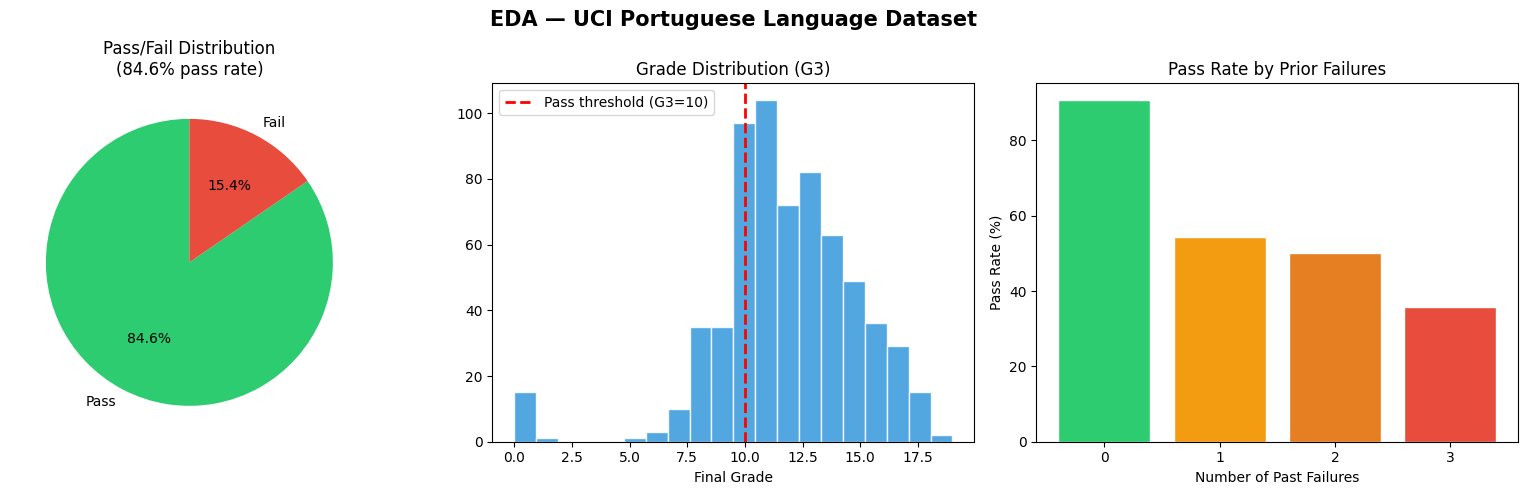

✅ eda_overview.png saved!


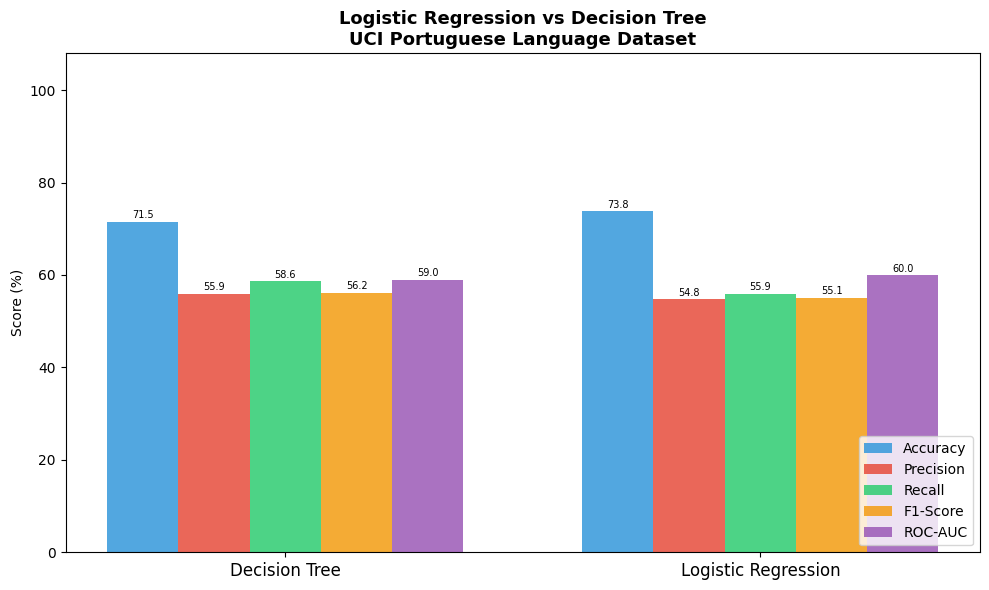

✅ model_comparison.png saved!


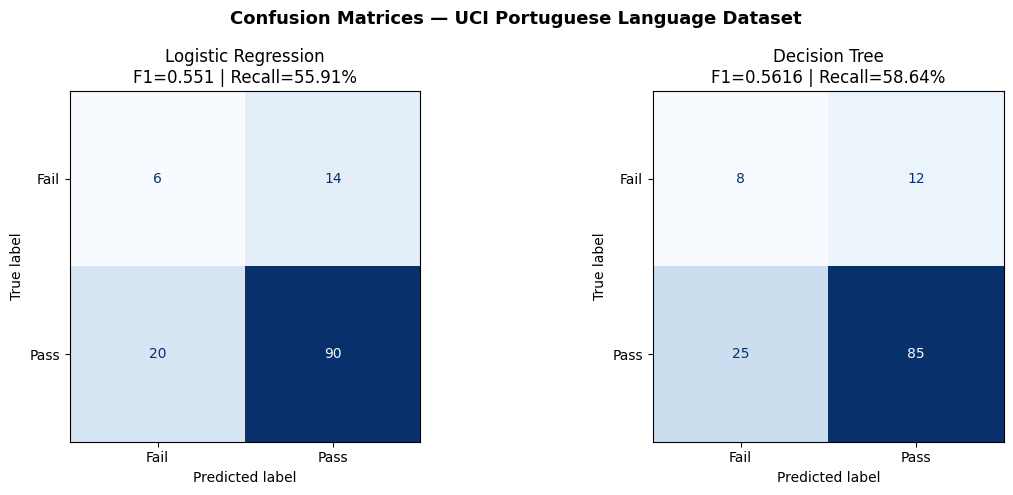

✅ confusion_matrices.png saved!


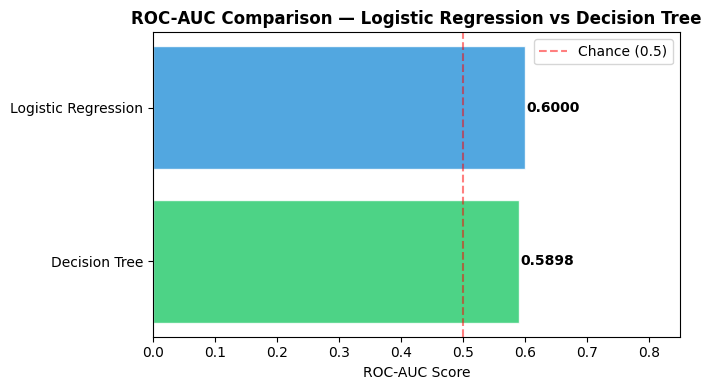

✅ roc_auc_comparison.png saved!
✅ model_results.csv saved!

✅ CELL 6 DONE — All result charts saved!


In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 6: SAVE RESULT CHARTS
# ═══════════════════════════════════════════════════════════

# ── Chart 1: EDA Overview ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — UCI Portuguese Language Dataset', fontsize=15, fontweight='bold')

# Pass/Fail distribution
counts = pd.Series(y).value_counts()
axes[0].pie(counts, labels=['Pass','Fail'], colors=['#2ecc71','#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Pass/Fail Distribution\n(84.6% pass rate)')

# Grade distribution
axes[1].hist(df_raw['G3'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Pass threshold (G3=10)')
axes[1].set_title('Grade Distribution (G3)')
axes[1].set_xlabel('Final Grade'); axes[1].legend()

# Pass rate by prior failures
fail_groups = df_raw.groupby('failures')['G3'].apply(lambda x: (x>=10).mean()*100)
axes[2].bar(fail_groups.index.astype(str), fail_groups.values,
            color=['#2ecc71','#f39c12','#e67e22','#e74c3c'][:len(fail_groups)],
            edgecolor='white')
axes[2].set_title('Pass Rate by Prior Failures')
axes[2].set_xlabel('Number of Past Failures')
axes[2].set_ylabel('Pass Rate (%)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ eda_overview.png saved!')

# ── Chart 2: Model Comparison (side-by-side bar) ──
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_results))
w = 0.15
metrics = ['Accuracy', 'Precision', 'Recall']
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

ax.bar(x - w*2, df_results['Accuracy'],       w, label='Accuracy',  color='#3498db', alpha=0.85)
ax.bar(x - w,   df_results['Precision'],      w, label='Precision', color='#e74c3c', alpha=0.85)
ax.bar(x,       df_results['Recall'],         w, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x + w,   df_results['F1-Score']*100,   w, label='F1-Score',  color='#f39c12', alpha=0.85)
ax.bar(x + w*2, df_results['ROC-AUC']*100,    w, label='ROC-AUC',   color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_results.index, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_title('Logistic Regression vs Decision Tree\nUCI Portuguese Language Dataset',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 108)
# Add value labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ model_comparison.png saved!')

# ── Chart 3: Confusion Matrices (both models side by side) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — UCI Portuguese Language Dataset',
             fontsize=13, fontweight='bold')
for ax, name in zip(axes, ['Logistic Regression', 'Decision Tree']):
    yp = predictions[name][0]
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    f1 = results[name]['F1-Score']
    rc = results[name]['Recall']
    ax.set_title(f'{name}\nF1={f1} | Recall={rc}%')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ confusion_matrices.png saved!')

# ── Chart 4: ROC-AUC Comparison ──
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(df_results.index, df_results['ROC-AUC'],
               color=['#2ecc71','#3498db'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, df_results['ROC-AUC']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')
ax.set_xlabel('ROC-AUC Score')
ax.set_title('ROC-AUC Comparison — Logistic Regression vs Decision Tree',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.85)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Chance (0.5)')
ax.legend()
plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ roc_auc_comparison.png saved!')

# ── Save Results CSV ──
df_results.to_csv('model_results.csv')
print('✅ model_results.csv saved!')

print('\n✅ CELL 6 DONE — All result charts saved!')

Computing SHAP for Logistic Regression...
  LR SHAP shape: (130, 30)
Computing SHAP for Decision Tree...
  DT SHAP shape: (130, 30)


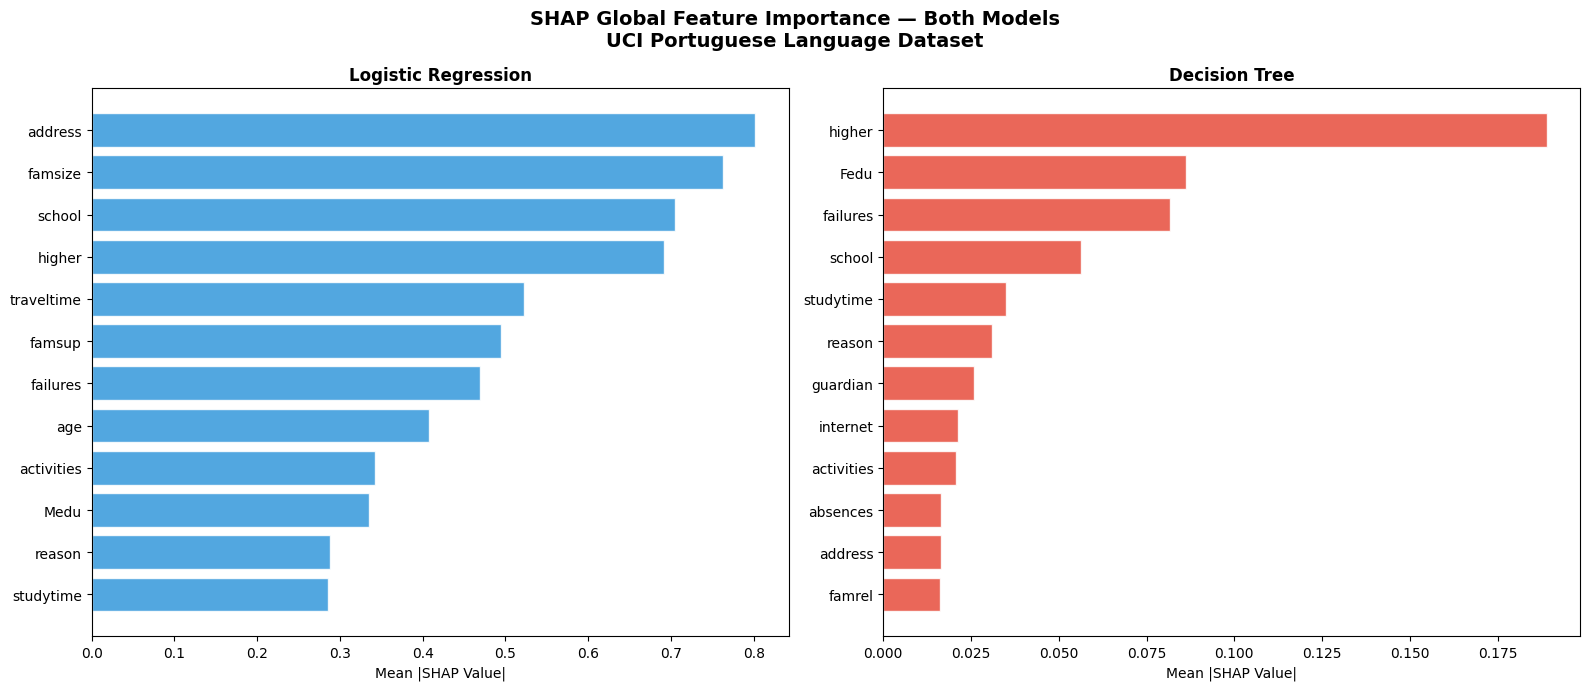

✅ shap_global.png saved!


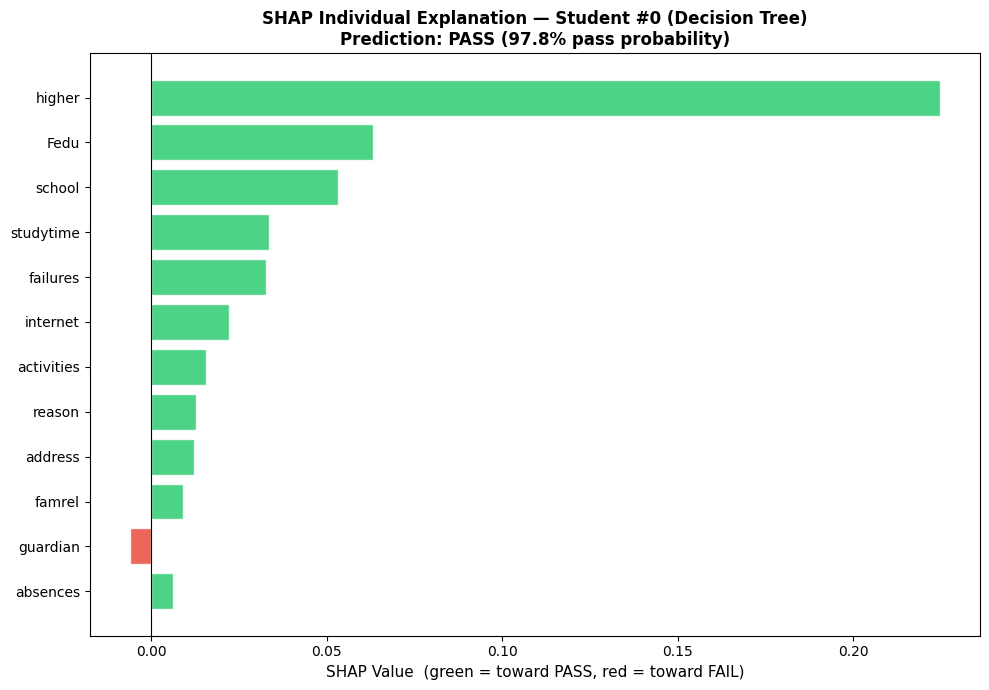

✅ shap_individual.png saved!


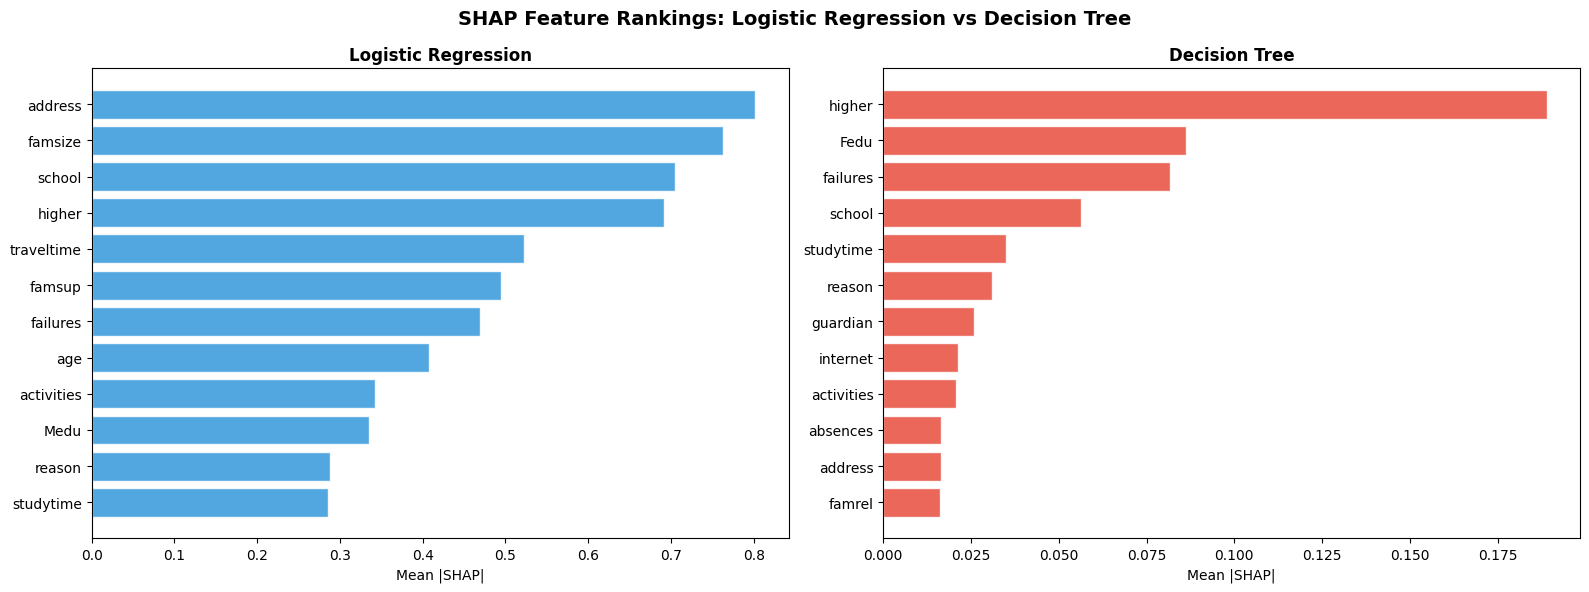

✅ shap_all_models.png saved!

✅ CELL 7 DONE — All SHAP charts saved!


In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 7: SHAP EXPLAINABILITY — BOTH MODELS
# ═══════════════════════════════════════════════════════════

shap_values_store = {}

# ── Logistic Regression: LinearExplainer ──
print('Computing SHAP for Logistic Regression...')
lr_explainer = shap.LinearExplainer(trained_models['Logistic Regression'],
                                     X_train_s, feature_perturbation='interventional')
sv_lr = lr_explainer.shap_values(X_test_s)
shap_values_store['Logistic Regression'] = sv_lr
print(f'  LR SHAP shape: {sv_lr.shape}')

# ── Decision Tree: TreeExplainer ──
print('Computing SHAP for Decision Tree...')
dt_explainer = shap.TreeExplainer(trained_models['Decision Tree'])
sv_dt_raw = dt_explainer.shap_values(X_test_s)
# TreeExplainer may return [class0, class1] — take class 1 (Pass)
if isinstance(sv_dt_raw, list):
    sv_dt = sv_dt_raw[1]
elif hasattr(sv_dt_raw, 'ndim') and sv_dt_raw.ndim == 3:
    sv_dt = sv_dt_raw[:, :, 1]
else:
    sv_dt = sv_dt_raw
shap_values_store['Decision Tree'] = sv_dt
print(f'  DT SHAP shape: {sv_dt.shape}')

# ── Chart 1: Global Feature Importance — Both Models Side by Side ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('SHAP Global Feature Importance — Both Models\nUCI Portuguese Language Dataset',
             fontsize=14, fontweight='bold')

for ax, (name, sv, color) in zip(axes, [
    ('Logistic Regression', sv_lr, '#3498db'),
    ('Decision Tree',       sv_dt, '#e74c3c')
]):
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-12:].astype(int)
    ax.barh([feature_names[i] for i in top_idx], mean_abs[top_idx],
            color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ shap_global.png saved!')

# ── Chart 2: Individual Student Explanation (best model) ──
best_sv = shap_values_store[best_name]
student_idx = 0
sv_student  = best_sv[student_idx]
s_idx       = np.argsort(np.abs(sv_student))[-12:].astype(int)
bar_cols    = ['#e74c3c' if v < 0 else '#2ecc71' for v in sv_student[s_idx]]

pred = trained_models[best_name].predict(X_test_s[student_idx:student_idx+1])[0]
prob = trained_models[best_name].predict_proba(X_test_s[student_idx:student_idx+1])[0][1]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([feature_names[i] for i in s_idx], sv_student[s_idx],
        color=bar_cols, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value  (green = toward PASS, red = toward FAIL)', fontsize=11)
ax.set_title(f'SHAP Individual Explanation — Student #0 ({best_name})\n'
             f'Prediction: {"PASS" if pred==1 else "FAIL"} ({prob*100:.1f}% pass probability)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_individual.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ shap_individual.png saved!')

# ── Chart 3: SHAP Comparison — LR vs DT top features overlap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Feature Rankings: Logistic Regression vs Decision Tree',
             fontsize=14, fontweight='bold')

lr_mean = np.abs(sv_lr).mean(axis=0)
dt_mean = np.abs(sv_dt).mean(axis=0)

# Rank by LR importance, show same features in DT
top_lr = np.argsort(lr_mean)[-12:].astype(int)
top_dt = np.argsort(dt_mean)[-12:].astype(int)
# Use union of top features
top_union = list(set(list(top_lr) + list(top_dt)))[:12]

axes[0].barh([feature_names[i] for i in np.argsort(lr_mean)[-12:]], lr_mean[np.argsort(lr_mean)[-12:]], color='#3498db', alpha=0.85, edgecolor='white')
axes[0].set_title('Logistic Regression', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP|')

axes[1].barh([feature_names[i] for i in np.argsort(dt_mean)[-12:]], dt_mean[np.argsort(dt_mean)[-12:]], color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].set_title('Decision Tree', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP|')

plt.tight_layout()
plt.savefig('shap_all_models.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ shap_all_models.png saved!')

print('\n✅ CELL 7 DONE — All SHAP charts saved!')

LIME Explanation for Student #0 (Decision Tree):
  school <= -0.87                                +0.2925  toward PASS ↑
  failures <= -0.52                              +0.1940  toward PASS ↑
  Fedu > 0.99                                    +0.0918  toward PASS ↑
  -0.78 < activities <= 1.28                     +0.0455  toward PASS ↑
  guardian <= 0.37                               +0.0397  toward PASS ↑
  Dalc <= -0.53                                  +0.0283  toward PASS ↑
  romantic <= -0.64                              -0.0192  toward FAIL ↓
  -0.10 < Medu <= 0.80                           +0.0144  toward PASS ↑
  freetime <= -0.21                              +0.0118  toward PASS ↑
  Walc <= -1.03                                  -0.0116  toward FAIL ↓


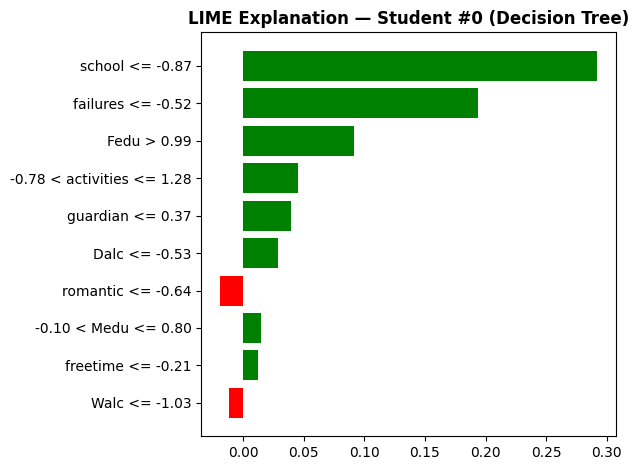

✅ lime_individual.png saved!


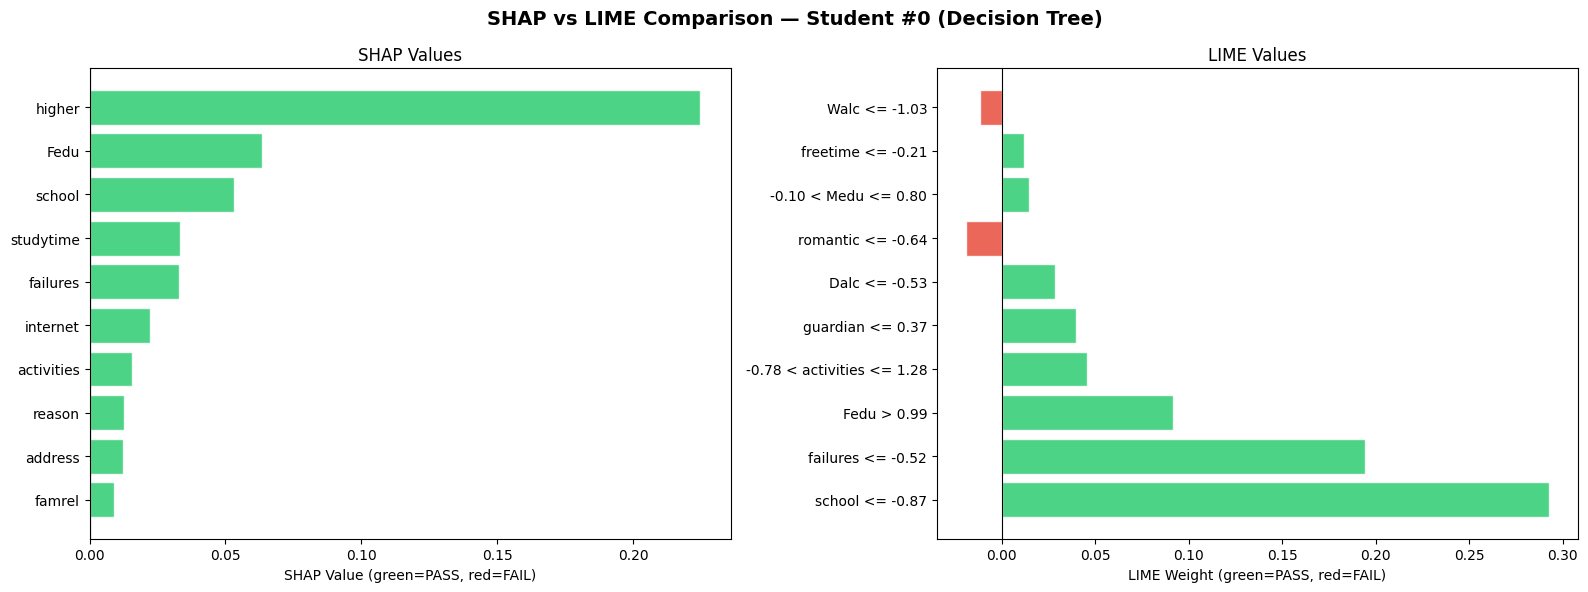

✅ shap_vs_lime.png saved!

✅ CELL 8 DONE — LIME charts saved!


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 8: LIME EXPLAINABILITY
# ═══════════════════════════════════════════════════════════
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_s,
    feature_names=feature_names,
    class_names=['Fail', 'Pass'],
    mode='classification',
    random_state=42
)

# Explain same student #0 with best model
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_s[0],
    predict_fn=trained_models[best_name].predict_proba,
    num_features=10
)

print(f'LIME Explanation for Student #0 ({best_name}):')
for feat, weight in lime_exp.as_list():
    direction = 'toward PASS ↑' if weight > 0 else 'toward FAIL ↓'
    print(f'  {feat:45s}  {weight:+.4f}  {direction}')

fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Explanation — Student #0 ({best_name})', fontweight='bold')
plt.tight_layout()
plt.savefig('lime_individual.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ lime_individual.png saved!')

# ── SHAP vs LIME Side-by-Side ──
best_sv  = shap_values_store[best_name]
sv_s     = best_sv[0]
si       = np.argsort(np.abs(sv_s))[-10:].astype(int)
lime_list = lime_exp.as_list()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'SHAP vs LIME Comparison — Student #0 ({best_name})',
             fontsize=14, fontweight='bold')

c_shap = ['#e74c3c' if v<0 else '#2ecc71' for v in sv_s[si]]
axes[0].barh([feature_names[i] for i in si], sv_s[si], color=c_shap, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('SHAP Values', fontsize=12)
axes[0].set_xlabel('SHAP Value (green=PASS, red=FAIL)')

lime_feats   = [f for f,w in lime_list]
lime_weights = [w for f,w in lime_list]
c_lime = ['#e74c3c' if v<0 else '#2ecc71' for v in lime_weights]
axes[1].barh(lime_feats, lime_weights, color=c_lime, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('LIME Values', fontsize=12)
axes[1].set_xlabel('LIME Weight (green=PASS, red=FAIL)')

plt.tight_layout()
plt.savefig('shap_vs_lime.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ shap_vs_lime.png saved!')

print('\n✅ CELL 8 DONE — LIME charts saved!')

Fairness Evaluation — Gender Attribute

Logistic Regression:
  Female predicted pass rate: 81.3%
  Male predicted pass rate:   78.2%
  Demographic Parity Difference: 3.2% — ✅ FAIR
         Accuracy     Recall   F1-Score
Group                                  
Female  74.666667  81.818182  85.039370
Male    72.727273  81.818182  82.758621

Decision Tree:
  Female predicted pass rate: 77.3%
  Male predicted pass rate:   70.9%
  Demographic Parity Difference: 6.4% — ✅ FAIR
         Accuracy     Recall   F1-Score
Group                                  
Female  73.333333  78.787879  83.870968
Male    69.090909  75.000000  79.518072


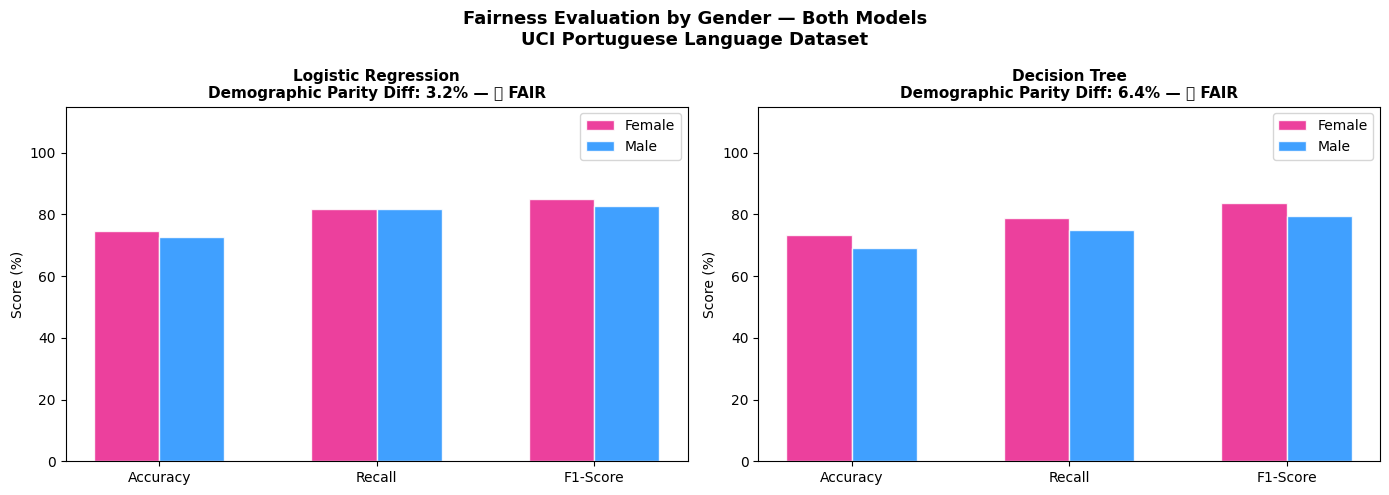


✅ fairness_gender.png saved!


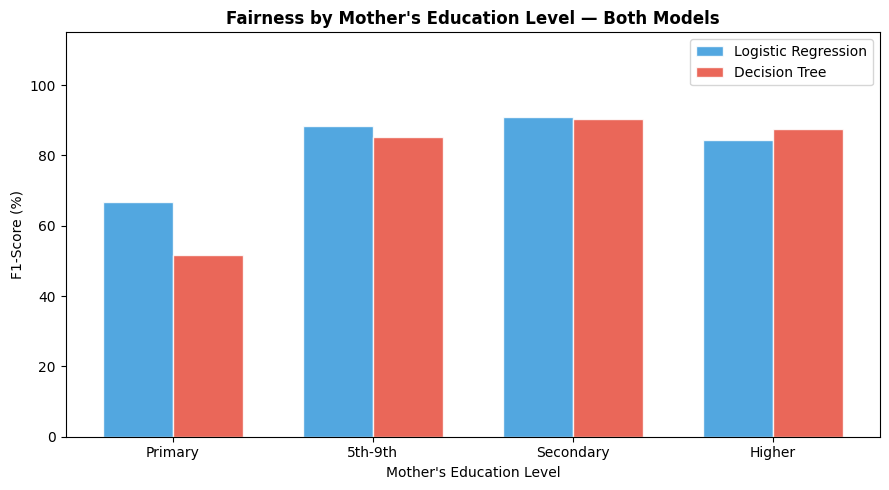

✅ fairness_education.png saved!

✅ CELL 9 DONE — Fairness charts saved!


In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 9: FAIRNESS EVALUATION
# ═══════════════════════════════════════════════════════════

X_test_df         = X_test.copy()
X_test_df['true'] = y_test.values

print('Fairness Evaluation — Gender Attribute')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fairness Evaluation by Gender — Both Models\nUCI Portuguese Language Dataset',
             fontsize=13, fontweight='bold')

for ax, (name, color) in zip(axes, [
    ('Logistic Regression', '#3498db'),
    ('Decision Tree',       '#e74c3c')
]):
    X_test_df['pred'] = trained_models[name].predict(X_test_s)

    gender_data = []
    for code, label in [(0,'Female'), (1,'Male')]:
        g = X_test_df[X_test_df['sex'] == code]
        if len(g) == 0: continue
        gender_data.append({
            'Group':    label,
            'Accuracy': accuracy_score(g['true'], g['pred']) * 100,
            'Recall':   recall_score(g['true'], g['pred'], zero_division=0) * 100,
            'F1-Score': f1_score(g['true'], g['pred'], zero_division=0) * 100
        })

    gdf = pd.DataFrame(gender_data).set_index('Group')
    x = np.arange(len(gdf.columns))
    w = 0.3
    ax.bar(x - w/2, gdf.loc['Female'], w, label='Female', color='#e91e8c', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, gdf.loc['Male'],   w, label='Male',   color='#1e90ff', alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(gdf.columns)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 115)
    ax.legend()

    f_rate = X_test_df[X_test_df['sex']==0]['pred'].mean() * 100
    m_rate = X_test_df[X_test_df['sex']==1]['pred'].mean() * 100
    diff   = abs(f_rate - m_rate)
    verdict = '✅ FAIR' if diff < 10 else '⚠️ BIAS'
    ax.set_title(f'{name}\nDemographic Parity Diff: {diff:.1f}% — {verdict}',
                 fontsize=11, fontweight='bold')

    print(f'\n{name}:')
    print(f'  Female predicted pass rate: {f_rate:.1f}%')
    print(f'  Male predicted pass rate:   {m_rate:.1f}%')
    print(f'  Demographic Parity Difference: {diff:.1f}% — {verdict}')
    print(gdf.to_string())

plt.tight_layout()
plt.savefig('fairness_gender.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('\n✅ fairness_gender.png saved!')

# ── Fairness by Mother Education ──
X_test_df['pred_lr'] = trained_models['Logistic Regression'].predict(X_test_s)
X_test_df['pred_dt'] = trained_models['Decision Tree'].predict(X_test_s)

edu_labels = {0:'None',1:'Primary',2:'5th-9th',3:'Secondary',4:'Higher'}
edu_rows_lr, edu_rows_dt, edu_labs = [], [], []
for code, label in edu_labels.items():
    g = X_test_df[X_test_df['Medu'] == code]
    if len(g) < 3: continue
    edu_rows_lr.append(f1_score(g['true'], g['pred_lr'], zero_division=0) * 100)
    edu_rows_dt.append(f1_score(g['true'], g['pred_dt'], zero_division=0) * 100)
    edu_labs.append(label)

x = np.arange(len(edu_labs))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, edu_rows_lr, w, label='Logistic Regression', color='#3498db', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, edu_rows_dt, w, label='Decision Tree',       color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(edu_labs)
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 115)
ax.set_title("Fairness by Mother's Education Level — Both Models", fontsize=12, fontweight='bold')
ax.set_xlabel("Mother's Education Level")
ax.legend()
plt.tight_layout()
plt.savefig('fairness_education.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('✅ fairness_education.png saved!')

print('\n✅ CELL 9 DONE — Fairness charts saved!')

In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 10: CROSS VALIDATION
# ═══════════════════════════════════════════════════════════
print('10-Fold Stratified Cross-Validation — Both Models')
print('=' * 55)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = []

for name in model_defs:
    m      = copy.deepcopy(model_defs[name])
    scores = cross_val_score(m, X.values, y.values, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    cv_results.append({
        'Model':       name,
        'CV F1 Mean':  round(scores.mean(), 4),
        'CV F1 Std':   round(scores.std(),  4),
        'Min F1':      round(scores.min(),  4),
        'Max F1':      round(scores.max(),  4),
    })
    print(f'  {name:25s}  F1={scores.mean():.4f} (±{scores.std():.4f})  '
          f'min={scores.min():.4f}  max={scores.max():.4f}')

df_cv = pd.DataFrame(cv_results).set_index('Model')
df_cv.to_csv('cross_validation_results.csv')
print('\n', df_cv.to_string())
print('\n✅ cross_validation_results.csv saved!')
print('\n✅ CELL 10 DONE — Cross validation complete!')

10-Fold Stratified Cross-Validation — Both Models
  Logistic Regression        F1=0.6028 (±0.0979)  min=0.4483  max=0.7631
  Decision Tree              F1=0.6316 (±0.0508)  min=0.5601  max=0.7045

                      CV F1 Mean  CV F1 Std  Min F1  Max F1
Model                                                     
Logistic Regression      0.6028     0.0979  0.4483  0.7631
Decision Tree            0.6316     0.0508  0.5601  0.7045

✅ cross_validation_results.csv saved!

✅ CELL 10 DONE — Cross validation complete!


In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 11: STREAMLIT DASHBOARD
# ═══════════════════════════════════════════════════════════
import time
from pyngrok import ngrok

with open('dashboard.py', 'w') as f:
    f.write("""
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import copy, urllib.request, zipfile, os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import shap
import lime, lime.lime_tabular

st.set_page_config(page_title='Student Performance Predictor', layout='wide')

@st.cache_resource
def load_and_train():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
    if not os.path.exists('student.zip'):
        urllib.request.urlretrieve(url, 'student.zip')
    with zipfile.ZipFile('student.zip','r') as z:
        z.extractall('student_data')

    df_raw = pd.read_csv('student_data/student-por.csv', sep=';')
    df = df_raw.copy()
    df['target'] = (df['G3'] >= 10).astype(int)
    df = df.drop(columns=['G1','G2','G3'])
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = LabelEncoder().fit_transform(df[col])

    X = df.drop(columns=['target']); y = df['target']
    fn = X.columns.tolist()
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_tr_b, y_tr_b = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_b); X_te_s = sc.transform(X_te)

    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=5)
    }
    trained, results = {}, {}
    for name, m in models.items():
        m = copy.deepcopy(m); m.fit(X_tr_s, y_tr_b)
        yp = m.predict(X_te_s); yb = m.predict_proba(X_te_s)[:,1]
        trained[name] = m
        results[name] = {
            'Accuracy':  round(accuracy_score(y_te, yp)*100,2),
            'Precision': round(precision_score(y_te,yp,average='macro',zero_division=0)*100,2),
            'Recall':    round(recall_score(y_te,yp,average='macro',zero_division=0)*100,2),
            'F1-Score':  round(f1_score(y_te,yp,average='macro',zero_division=0),4),
        }
    return trained, results, sc, fn, X_te_s, y_te, X_te, X_tr_s, y_tr_b, df_raw

with st.sidebar:
    st.markdown('## 🎓 Navigation')
    page = st.radio('Go to:', ['🏠 Home','📊 Dataset','🤖 Models',
                                '🔍 Predict','💡 SHAP','⚖️ Fairness'])
    st.markdown('---')
    st.markdown('**MSc Research Project**')
    st.markdown('Student Performance Prediction')
    st.markdown('UCI Portuguese Language Dataset')

with st.spinner('Loading and training models...'):
    tm, res, sc, fn, Xte, yte, Xte_r, Xtr_s, ytr_b, df_raw = load_and_train()

best = max(res, key=lambda x: res[x]['F1-Score'])

if page == '🏠 Home':
    st.title('🎓 Student Performance Predictor')
    st.markdown('**Dataset:** UCI Portuguese Language (649 students) | **Models:** Logistic Regression & Decision Tree')
    st.success(f'🏆 Best Model (F1): **{best}** — F1: {res[best]["F1-Score"]}')
    c1, c2 = st.columns(2)
    c1.info('**📈 Predict** student risk'); c2.success('**💡 Explain** with SHAP')
    st.subheader('Model Results')
    st.dataframe(pd.DataFrame(res).T, use_container_width=True)

elif page == '📊 Dataset':
    st.header('📊 Dataset Overview — UCI Portuguese Language')
    st.markdown(f'**649 students | 30 features | Pass rate: {(df_raw["G3"]>=10).mean()*100:.1f}%**')
    col1, col2 = st.columns(2)
    with col1:
        fig, ax = plt.subplots(figsize=(5,4))
        pn = (df_raw['G3']>=10).sum(); fn2 = (df_raw['G3']<10).sum()
        ax.pie([pn,fn2], labels=['Pass','Fail'], colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%')
        st.pyplot(fig); plt.close()
    with col2:
        fig, ax = plt.subplots(figsize=(5,4))
        ax.hist(df_raw['G3'], bins=20, color='#3498db', edgecolor='white')
        ax.axvline(x=10, color='red', linestyle='--', label='Pass threshold'); ax.legend()
        ax.set_xlabel('Final Grade (G3)'); ax.set_title('Grade Distribution')
        st.pyplot(fig); plt.close()
    st.dataframe(df_raw.head(10), use_container_width=True)

elif page == '🤖 Models':
    st.header('🤖 Model Comparison')
    df_r = pd.DataFrame(res).T
    st.dataframe(df_r, use_container_width=True)
    sel = st.selectbox('Confusion Matrix:', list(tm.keys()))
    yp  = tm[sel].predict(Xte)
    cm  = confusion_matrix(yte, yp)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(sel)
    st.pyplot(fig); plt.close()

elif page == '🔍 Predict':
    st.header('🔍 Predict a Student')
    mc = st.selectbox('Model:', list(tm.keys()))
    c1, c2, c3 = st.columns(3)
    with c1:
        age      = st.slider('Age', 15, 22, 17)
        absences = st.slider('Absences', 0, 93, 5)
        studytime = st.slider('Study Time (1=<2h, 4=>10h)', 1, 4, 2)
    with c2:
        failures = st.slider('Past Failures', 0, 3, 0)
        Medu = st.slider('Mother Education (0-4)', 0, 4, 2)
        Fedu = st.slider('Father Education (0-4)', 0, 4, 2)
    with c3:
        sex      = st.selectbox('Gender', ['Female','Male'])
        internet = st.selectbox('Internet Access', ['Yes','No'])
        higher   = st.selectbox('Wants Higher Education', ['Yes','No'])
    if st.button('🎯 Predict Now', type='primary', use_container_width=True):
        inp = {n: 0 for n in fn}
        inp.update({'age': age, 'absences': absences, 'studytime': studytime,
                    'failures': failures, 'Medu': Medu, 'Fedu': Fedu,
                    'sex': 1 if sex=='Male' else 0,
                    'internet': 1 if internet=='Yes' else 0,
                    'higher': 1 if higher=='Yes' else 0,
                    'famrel': 3, 'health': 3, 'traveltime': 1, 'freetime': 3, 'goout': 3})
        Xi   = sc.transform(pd.DataFrame([inp])[fn])
        pred = tm[mc].predict(Xi)[0]
        prob = tm[mc].predict_proba(Xi)[0][1]
        ca, cb = st.columns(2)
        with ca:
            st.success('## ✅ PASS') if pred==1 else st.error('## ❌ FAIL')
        with cb:
            st.metric('Pass Probability', f'{prob*100:.1f}%')
            st.metric('Fail Probability', f'{(1-prob)*100:.1f}%')
        if prob >= 0.75:   st.success('🟢 LOW RISK')
        elif prob >= 0.5:  st.warning('🟡 MEDIUM RISK')
        else:              st.error('🔴 HIGH RISK — Intervention recommended')

elif page == '💡 SHAP':
    st.header('💡 SHAP Explainability')
    mc = st.selectbox('Model:', list(tm.keys()))
    m  = tm[mc]
    with st.spinner('Computing SHAP values...'):
        if mc == 'Logistic Regression':
            exp = shap.LinearExplainer(m, Xtr_s, feature_perturbation='interventional')
            sv  = exp.shap_values(Xte)
        else:
            exp    = shap.TreeExplainer(m)
            sv_raw = exp.shap_values(Xte)
            sv = sv_raw[1] if isinstance(sv_raw, list) else (sv_raw[:,:,1] if sv_raw.ndim==3 else sv_raw)
    ma  = np.abs(sv).mean(axis=0)
    ti  = np.argsort(ma)[-12:].astype(int)
    fig, ax = plt.subplots(figsize=(9,6))
    ax.barh([fn[i] for i in ti], ma[ti], color='#3498db', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Mean |SHAP Value|'); ax.set_title(f'Top 12 Features — {mc}')
    st.pyplot(fig); plt.close()

    idx = st.slider('Select Student:', 0, len(Xte)-1, 0)
    p   = m.predict(Xte[idx:idx+1])[0]
    pb  = m.predict_proba(Xte[idx:idx+1])[0][1]
    c1, c2, c3 = st.columns(3)
    c1.metric('Prediction', 'PASS ✅' if p==1 else 'FAIL ❌')
    c2.metric('Pass Probability', f'{pb*100:.1f}%')
    c3.metric('Actual', 'PASS ✅' if yte.iloc[idx]==1 else 'FAIL ❌')

    sv_s = sv[idx]; si = np.argsort(np.abs(sv_s))[-10:].astype(int)
    cols = ['#e74c3c' if v<0 else '#2ecc71' for v in sv_s[si]]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh([fn[i] for i in si], sv_s[si], color=cols, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Student #{idx} — {"PASS" if p==1 else "FAIL"} ({pb*100:.1f}%) | {mc}')
    st.pyplot(fig); plt.close()

    # Plain language summary
    top_feat  = fn[np.argmax(np.abs(sv_s))]
    direction = 'toward PASS' if sv_s[np.argmax(np.abs(sv_s))] > 0 else 'toward FAIL'
    st.info(f'**Plain-language summary:** This student is flagged primarily due to **{top_feat}** ({direction}). '
            f'The model predicts {"PASS" if p==1 else "FAIL"} with {pb*100:.1f}% pass probability. '
            f'Educator judgement should guide any intervention decision.')

elif page == '⚖️ Fairness':
    st.header('⚖️ Fairness Analysis — Gender')
    mc = st.selectbox('Model:', list(tm.keys()))
    yp = tm[mc].predict(Xte)
    df_ev = Xte_r.copy(); df_ev['true'] = yte.values; df_ev['pred'] = yp
    rows = []
    for code, label in [(0,'Female'),(1,'Male')]:
        g = df_ev[df_ev['sex']==code]
        if len(g)==0: continue
        rows.append({'Group': label, 'Students': len(g),
                     'Actual Pass Rate':    f"{g['true'].mean()*100:.1f}%",
                     'Predicted Pass Rate': f"{g['pred'].mean()*100:.1f}%",
                     'F1-Score': f"{f1_score(g['true'],g['pred'],zero_division=0):.3f}"})
    st.dataframe(pd.DataFrame(rows).set_index('Group'), use_container_width=True)
    fr   = df_ev[df_ev['sex']==0]['pred'].mean()*100
    mr   = df_ev[df_ev['sex']==1]['pred'].mean()*100
    diff = abs(fr-mr)
    c1,c2,c3 = st.columns(3)
    c1.metric('Female Pass Rate', f'{fr:.1f}%')
    c2.metric('Male Pass Rate',   f'{mr:.1f}%')
    c3.metric('Dem. Parity Diff', f'{diff:.1f}%')
    if diff < 10: st.success(f'✅ FAIR — {diff:.1f}% difference, under 10% threshold (80% rule satisfied)')
    else:         st.error(f'⚠️ POTENTIAL BIAS — {diff:.1f}% exceeds 10% threshold')
    st.caption('Note: This is a simplified fairness check. Full Fairlearn analysis (DPD, EOD, DIR) is in the notebook.')
""")

print('✅ dashboard.py written!')

ngrok.set_auth_token('3CXFKb9LmdHo7iZjGUkVn5u90Uz_5ad5siX9BHXmu89GYv7XX')  # Replace with your ngrok token
ngrok.kill()
import subprocess
subprocess.run(['pkill','-f','streamlit'], capture_output=True)
subprocess.run(['pkill','-f','ngrok'],     capture_output=True)
time.sleep(3)

proc = subprocess.Popen(
    ['streamlit','run','dashboard.py','--server.port','8501','--server.headless','true'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(6)

public_url = ngrok.connect(8501)
print(f'🚀 Dashboard LIVE at: {public_url}')
print('\n✅ CELL 11 DONE — Dashboard launched!')

✅ dashboard.py written!
🚀 Dashboard LIVE at: NgrokTunnel: "https://transport-flop-scrubbed.ngrok-free.dev" -> "http://localhost:8501"

✅ CELL 11 DONE — Dashboard launched!


In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 12: CHECK ALL FILES EXIST
# ═══════════════════════════════════════════════════════════
import os

all_files = [
    'model_results.csv',
    'cross_validation_results.csv',
    'eda_overview.png',
    'model_comparison.png',
    'confusion_matrices.png',
    'roc_auc_comparison.png',
    'shap_global.png',
    'shap_individual.png',
    'shap_all_models.png',
    'lime_individual.png',
    'shap_vs_lime.png',
    'fairness_gender.png',
    'fairness_education.png',
]

print('File Status:')
print('─' * 50)
found, missing = [], []
for f in all_files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f'  ✅ {f:40s} ({size:,} bytes)')
        found.append(f)
    else:
        print(f'  ❌ {f:40s} NOT FOUND')
        missing.append(f)

print('─' * 50)
print(f'\n✅ Found:   {len(found)} / {len(all_files)} files')
if missing:
    print(f'❌ Missing: {missing}')
else:
    print('\n🎉 All files ready — run Cell 13 to download!')

File Status:
──────────────────────────────────────────────────
  ✅ model_results.csv                        (138 bytes)
  ✅ cross_validation_results.csv             (131 bytes)
  ✅ eda_overview.png                         (91,242 bytes)
  ✅ model_comparison.png                     (60,804 bytes)
  ✅ confusion_matrices.png                   (52,378 bytes)
  ✅ roc_auc_comparison.png                   (41,367 bytes)
  ✅ shap_global.png                          (93,247 bytes)
  ✅ shap_individual.png                      (67,127 bytes)
  ✅ shap_all_models.png                      (85,276 bytes)
  ✅ lime_individual.png                      (50,026 bytes)
  ✅ shap_vs_lime.png                         (99,073 bytes)
  ✅ fairness_gender.png                      (61,415 bytes)
  ✅ fairness_education.png                   (44,062 bytes)
──────────────────────────────────────────────────

✅ Found:   13 / 13 files

🎉 All files ready — run Cell 13 to download!


In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 13: DOWNLOAD ALL FILES
# ═══════════════════════════════════════════════════════════
from google.colab import files
import time, os

download_list = [
    ('model_results.csv',            '📊 Results table'),
    ('cross_validation_results.csv', '📊 Cross validation'),
    ('eda_overview.png',             '📈 EDA chart'),
    ('model_comparison.png',         '📈 Model comparison'),
    ('confusion_matrices.png',       '📈 Confusion matrices'),
    ('roc_auc_comparison.png',       '📈 ROC-AUC chart'),
    ('shap_global.png',              '💡 SHAP global (both models)'),
    ('shap_individual.png',          '💡 SHAP individual'),
    ('shap_all_models.png',          '💡 SHAP LR vs DT comparison'),
    ('lime_individual.png',          '💡 LIME explanation'),
    ('shap_vs_lime.png',             '💡 SHAP vs LIME'),
    ('fairness_gender.png',          '⚖️ Fairness gender'),
    ('fairness_education.png',       '⚖️ Fairness education'),
]

print('Downloading files...')
print('─' * 50)
downloaded, skipped = [], []
for filename, description in download_list:
    if os.path.exists(filename):
        files.download(filename)
        time.sleep(1)
        print(f'  ✅ Downloaded: {description} — {filename}')
        downloaded.append(filename)
    else:
        print(f'  ❌ Skipped (not found): {filename}')
        skipped.append(filename)

print('─' * 50)
print(f'\n✅ Downloaded: {len(downloaded)} files')
print(f'❌ Skipped:    {len(skipped)} files')
print('\n✅ CELL 13 DONE — Check your Downloads folder!')

──────────────────────────────────────────────────


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: 📊 Results table — model_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Downloaded: ⚖️ Fairness gender — fairness_gender.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: ⚖️ Fairness education — fairness_education.png
──────────────────────────────────────────────────

✅ Downloaded: 13 files
❌ Skipped:    0 files

✅ CELL 13 DONE — Check your Downloads folder!
